In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

🎯 라벨 매핑: {'보통': 0, '좋다': 1}
📊 총 피처: 28 | 숫자형: 19 | 범주형: 9
🎯 클래스 분포(인코딩 후): {0: 1244, 1: 226}
🧱 입력 차원: 50, 클래스 수: 2
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               13056     
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Batc  (None, 128)              512       
 hNormalization)                                                 
       

C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53685 (\N{H

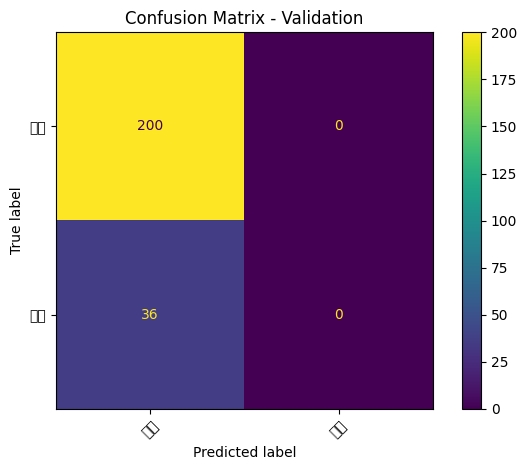


=== Test ===
accuracy: 0.8469 | precision_w: 0.7173 | recall_w: 0.8469 | f1_w: 0.7768

[Classification Report]
              precision    recall  f1-score   support

          보통       0.85      1.00      0.92       249
          좋다       0.00      0.00      0.00        45

    accuracy                           0.85       294
   macro avg       0.42      0.50      0.46       294
weighted avg       0.72      0.85      0.78       294

[Confusion Matrix]
[[249   0]
 [ 45   0]]


C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19408\2110903588.py:174: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53685 (\N{H

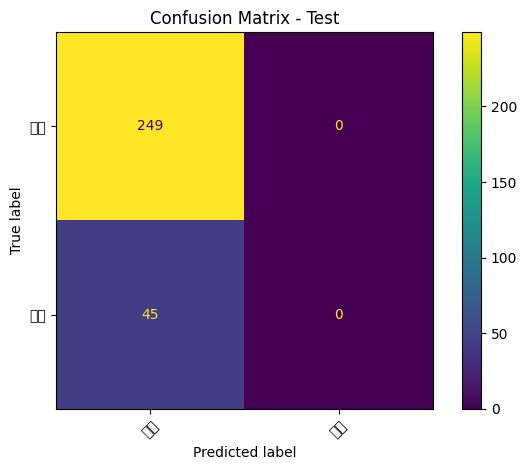

(0.8469387755102041, 0.717305289462724, 0.8469387755102041, 0.7767504791972037)

In [7]:
# -*- coding: utf-8 -*-
# ✅ 다중분류 DNN (TensorFlow Keras)
# - LabelEncoder로 타깃 문자열 → 정수
# - ColumnTransformer(표준화 + 원핫) 전처리
# - 학습/검증/테스트 분리 + 조기 종료
# - 성능 리포트/혼동행렬 출력
# ※ 필요한 패키지: pandas, numpy, scikit-learn, tensorflow, matplotlib(옵션)

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# 1) 데이터 로드
# =========================
# 👉 본인 경로로 수정
# 예) r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv"
CSV_PATH = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv"
TARGET_COL = "업무평가"   # 타깃 열 이름

df = pd.read_csv(CSV_PATH)
assert TARGET_COL in df.columns, f"타깃 열 '{TARGET_COL}' 없음"

# 불필요한 열 제거 (있으면 추가)
drop_cols = []  # 예: ["EmployeeNumber", "Unnamed: 0"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# =========================
# 2) 타깃 인코딩 & 피처 분리
# =========================
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])     # 문자열 → 정수
X = df.drop(columns=[TARGET_COL])

print("🎯 라벨 매핑:", dict(zip(le.classes_, range(len(le.classes_)))))

# 숫자/범주형 자동 구분
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"📊 총 피처: {X.shape[1]} | 숫자형: {len(num_cols)} | 범주형: {len(cat_cols)}")
print(f"🎯 클래스 분포(인코딩 후): {pd.Series(y).value_counts().sort_index().to_dict()}")

# =========================
# 3) 학습/검증/테스트 분리
# =========================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# =========================
# 4) 전처리 파이프라인 (버전 호환)
# =========================
# scikit-learn 1.2+ : OneHotEncoder(sparse_output=False)
# scikit-learn 1.1.x : OneHotEncoder(sparse=False)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

transformer = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
)

# fit on train only
X_train_t = transformer.fit_transform(X_train)
X_val_t   = transformer.transform(X_val)
X_test_t  = transformer.transform(X_test)

input_dim = X_train_t.shape[1]
n_classes = len(le.classes_)
print(f"🧱 입력 차원: {input_dim}, 클래스 수: {n_classes}")

# =========================
# 5) 클래스 가중치(옵션)
# =========================
USE_CLASS_WEIGHT = False
class_weight = None
if USE_CLASS_WEIGHT:
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
    print("⚖️ 클래스 가중치:", class_weight)

# =========================
# 6) 모델 정의
# =========================
def build_model(input_dim, n_classes, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),

        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(input_dim, n_classes, dropout=0.3, lr=1e-3)
model.summary()

# =========================
# 7) 학습
# =========================
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train_t, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val_t, y_val),
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weight
)

# =========================
# 8) 평가 함수
# =========================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_split(name, X_t, y_true, show_plot=True):
    y_proba = model.predict(X_t, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n=== {name} ===")
    print(f"accuracy: {acc:.4f} | precision_w: {p:.4f} | recall_w: {r:.4f} | f1_w: {f1:.4f}")
    print("\n[Classification Report]")
    # 원라벨로 보고 싶으면 target_names=le.classes_ 전달
    print(classification_report(y_true, y_pred, zero_division=0, target_names=le.classes_))
    print("[Confusion Matrix]")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    if show_plot:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
        disp.plot(xticks_rotation=45)
        plt.title(f"Confusion Matrix - {name}")
        plt.tight_layout()
        plt.show()

    return acc, p, r, f1

evaluate_split("Validation", X_val_t, y_val, show_plot=True)
evaluate_split("Test", X_test_t, y_test, show_plot=True)

# =========================
# 9) 신규 샘플 예측 예시
# =========================
# X.columns 순서에 맞는 dict를 넣으면 됨. (범주형은 원 문자열, 숫자형은 수치)
# sample = {
#     "나이": 35, "근속연수": 4, "직무만족도": 3, "부서": "Sales", ...
# }
# sample_df = pd.DataFrame([sample])[X.columns]   # 컬럼 순서 맞추기
# sample_t = transformer.transform(sample_df)
# pred_idx = np.argmax(model.predict(sample_t, verbose=0), axis=1)[0]
# print("예측 업무평가(정수):", pred_idx)
# print("예측 업무평가(원라벨):", le.inverse_transform([pred_idx])[0])

# =========================
# 10) (옵션) 저장
# =========================
# 모델 저장(.keras)
# model.save("dnn_multiclass_model.keras")
# 전처리기/라벨인코더 저장 (필요시)
# import joblib
# joblib.dump(transformer, "preprocess.joblib")
# joblib.dump(le, "label_encoder.joblib")
